<a href="https://colab.research.google.com/github/asiddiqha/ai-workbench/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=iris.feature_names)
df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca.head()

,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


In [6]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

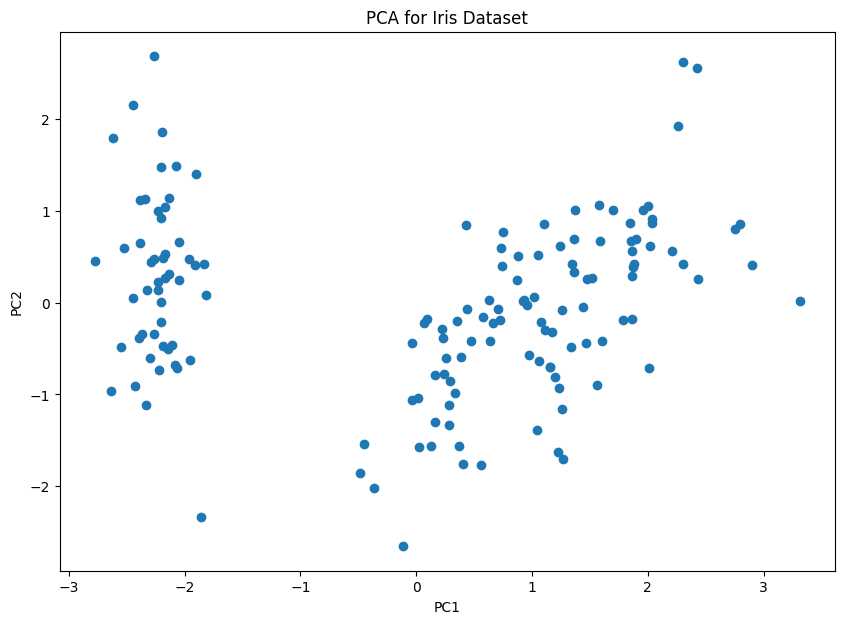

In [8]:
plt.figure(figsize=(10, 7))
plt.scatter(df_pca['PC1'], df_pca['PC2'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA for Iris Dataset')
plt.show()

DBCSAN for Anomalies

In [9]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [10]:
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

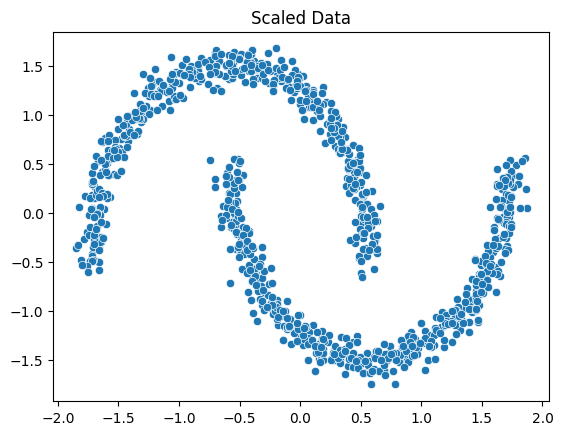

In [11]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1])
plt.title('Scaled Data')
plt.show()

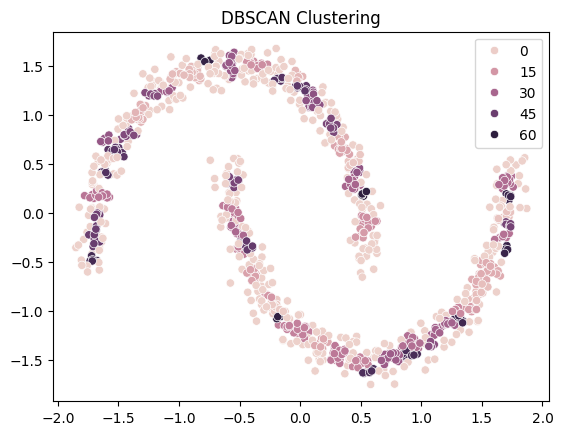

In [14]:
dbscan = DBSCAN(eps=0.05, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=clusters)
plt.title('DBSCAN Clustering')
plt.show()

Isolation Forest for Anomalies

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [17]:
df = pd.read_csv('thyroid_dataset.csv')
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [18]:
X = df.drop('Outlier_label', axis=1)
y = df['Outlier_label']

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
clf = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
labels = clf.fit_predict(X_scaled)
# df['anomaly_score'] = clf.decision_function(X_scaled)

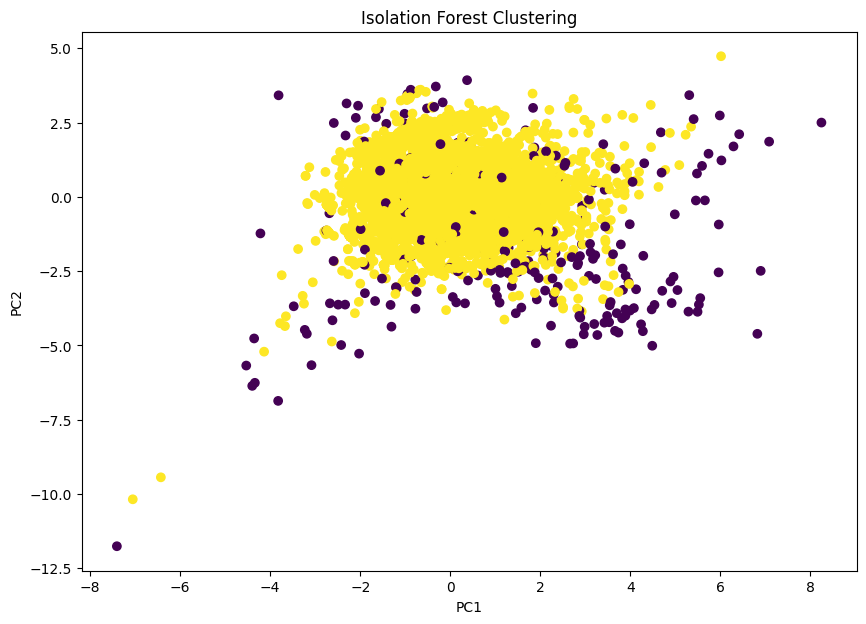

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Isolation Forest Clustering')
plt.show()

In [22]:
import numpy as np
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)
print(f'Number of outliers: {n_outliers}')
print(f'Number of normal: {n_normal}')

Number of outliers: 275
Number of normal: 6641


LOF for Anomalies

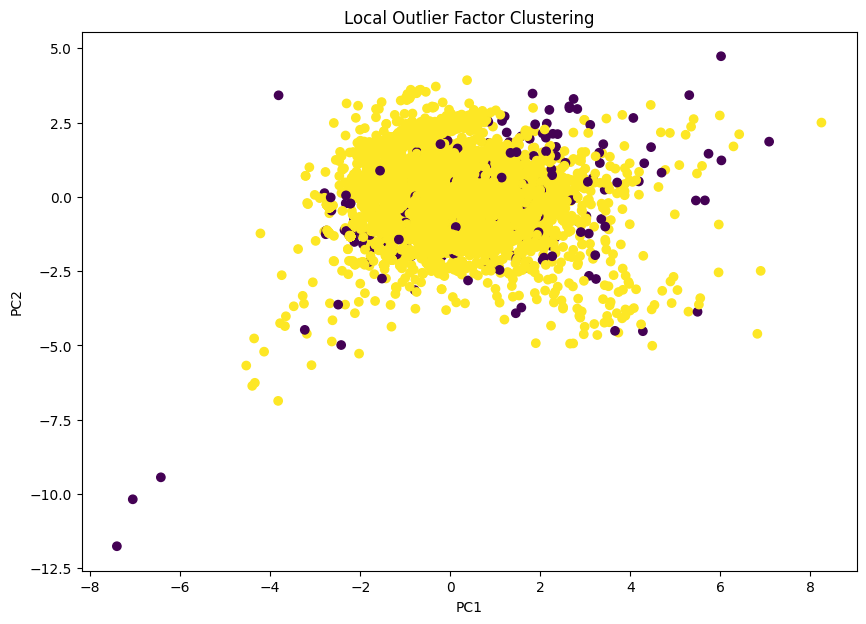

Number of outliers: 275
Number of normal: 6641


In [27]:
from sklearn.neighbors import LocalOutlierFactor

neighbours = LocalOutlierFactor(n_neighbors=20, contamination=0.036)
y_pred = neighbours.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Local Outlier Factor Clustering')
plt.show()

n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)
print(f'Number of outliers: {n_outliers}')
print(f'Number of normal: {n_normal}')